<a href="https://colab.research.google.com/github/jcmachicao/MachineLearningAvanzado_UC_2025/blob/main/U2_NN_regularizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Regularización en una red simple

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Dataset
X, y = make_moons(n_samples=1000, noise=0.2)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

In [3]:
# Modelo con Dropout
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model = Net()

In [4]:
# AdamW = regularización moderna
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

train_losses, val_losses = [], []

for epoch in range(100):
    model.train()
    logits = model(X_train)
    loss = F.cross_entropy(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_loss = F.cross_entropy(val_logits, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())


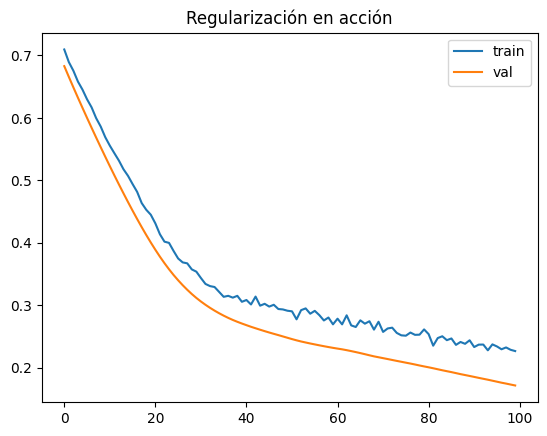

In [5]:
# Visualización
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("Regularización en acción")
plt.show()

## 🧪 Experimentos sugeridos

Quitar Dropout → observar overfitting

Cambiar weight_decay = 0 → comparar

Reducir dataset → ver efecto más fuerte

Añadir Early Stopping manual

##🧩 Conclusión final

Regularizar no es una técnica aislada.

Es una forma de pensar:

¿Cómo evito que mi modelo aprenda cosas que no debería aprender?

Y la respuesta puede venir desde:

* la perdida (loss)

* el optimizador

* la arquitectura

* los datos

Si se entiende esto, la regularización deja de ser una lista de trucos… y se convierte en una herramienta conceptual poderosa.